In [1]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
import xarray as xr
import rioxarray
import numpy as np
from pathlib import Path

vrt_dir = Path("../data/bronze/ghana-2022-jan/vrt_files")

# Bands to load
band_to_name = {
    "B02": "blue",
    "B03": "green",
    "B04": "red",
    "B05": "rededge",
    "B06": "B06",
    "B07": "B07",
    "B08": "nir",
    "B8A": "B8A",
    "B11": "swir11",
    "B12": "swir22",
}

# Load each band and assign a name
bands = {}
for band, name in band_to_name.items():
    # 2. Change extension to .vrt and add chunks=True for lazy loading
    da = rioxarray.open_rasterio(vrt_dir / f"{band}.vrt", masked=True, chunks=True)
    da = da.squeeze("band", drop=True)
    da = da.fillna(0).astype(np.uint8)
    bands[name] = da

# Combine into a Dataset — all bands aligned on (y, x)
ds = xr.Dataset(bands)

aux_names = ["cloud_confidence", "scene_classification", "valid_observations"]
for aux in aux_names:
    # 2. Change extension to .vrt and add chunks=True
    da = rioxarray.open_rasterio(vrt_dir / f"{aux}.vrt", masked=True, chunks=True)
    da = da.fillna(255).astype(np.uint8)
    ds[aux] = da.squeeze("band", drop=True)

print(ds)

RasterioIOError: ../data/bronze/ghana-2022-jan/vrt_files/B07.vrt: No such file or directory

In [11]:
# Only keep ashanti for now
import osmnx as ox
ashanti_gdf = ox.geocode_to_gdf("Ashanti Region, Ghana")
ds = ds.rio.clip(ashanti_gdf.geometry, crs=ashanti_gdf.crs, drop=True)

EPSG:4326


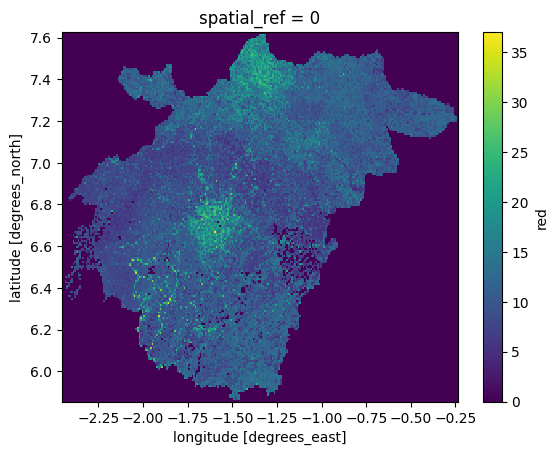

In [13]:
# Check CRS and resolution
print(ds.rio.crs)

# Downsample & plot
step = 100
ds_small = ds.isel(y=slice(None, None, step), x=slice(None, None, step))
ds_small.red.plot()

In [14]:
# Open the ETHZ data and clip to the bounding box
bounds = ds.rio.bounds()  # (left, bottom, right, top)
ethz_ds = rioxarray.open_rasterio("../data/bronze/cocoa_map.tif", masked=True)
ethz_ds.rio.write_nodata(np.nan, inplace=True)
print(ethz_ds.rio.crs)
clipped_ethz_ds = ethz_ds.rio.clip_box(*bounds)

EPSG:4326


In [15]:
clipped_ethz_reprojected_ds = clipped_ethz_ds.rio.reproject_match(ds)
ds["ethz_map"] = clipped_ethz_reprojected_ds.squeeze("band", drop=True)
print(ds)

<xarray.Dataset> Size: 8GB
Dimensions:               (x: 24608, y: 19647)
Coordinates:
  * x                     (x) float64 197kB -2.452 -2.451 ... -0.2378 -0.2377
  * y                     (y) float64 157kB 7.623 7.623 7.622 ... 5.855 5.855
    spatial_ref           int64 8B 0
Data variables: (12/14)
    blue                  (y, x) uint8 483MB dask.array<chunksize=(6596, 2525), meta=np.ndarray>
    green                 (y, x) uint8 483MB dask.array<chunksize=(6596, 2525), meta=np.ndarray>
    red                   (y, x) uint8 483MB dask.array<chunksize=(6596, 2525), meta=np.ndarray>
    rededge               (y, x) uint8 483MB dask.array<chunksize=(6596, 2525), meta=np.ndarray>
    B06                   (y, x) uint8 483MB dask.array<chunksize=(6596, 2525), meta=np.ndarray>
    B07                   (y, x) uint8 483MB dask.array<chunksize=(6596, 2525), meta=np.ndarray>
    ...                    ...
    swir11                (y, x) uint8 483MB dask.array<chunksize=(6596, 2525), met

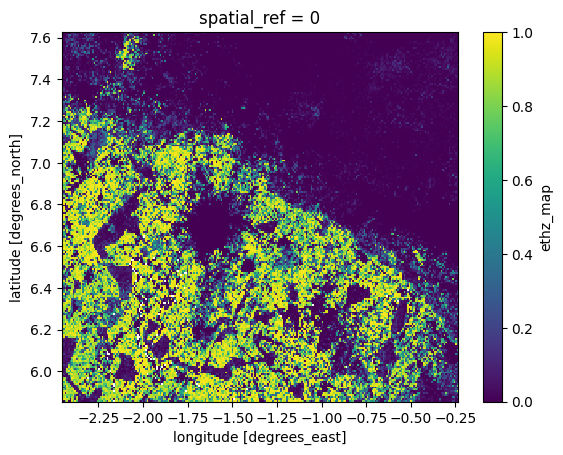

In [16]:
# Downsample and plot
step = 100
ds_small = ds.isel(y=slice(None, None, step), x=slice(None, None, step))
ds_small.ethz_map.plot()

In [17]:
# Ditch scale_factor and add_offset
for var in ds.data_vars:
    ds[var].attrs.pop('scale_factor', None)
    ds[var].attrs.pop('add_offset', None)
    ds[var].encoding.clear()

# Dump to disk
ds.to_netcdf("../data/silver/ashanti.nc")

/home/aga/Documents/clients/forestero/skymap/skymap/.venv/lib/python3.14/site-packages/dask/array/chunk.py:288: RuntimeWarning: invalid value encountered in cast
  return x.astype(astype_dtype, **kwargs)
